In [ ]:
import numpy as np
import math
import os
from scipy.optimize import minimize
from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
def generate_markov_trajectory(P, H, initial_distribution):
    n_states = P.shape[0]
    trajectory = np.zeros(H, dtype=int)

    current_state = np.random.choice(
        n_states,
        p=initial_distribution,
    )

    for t in range(H):
        trajectory[t] = current_state
        current_state = np.random.choice(
            n_states,
            p=P[current_state],
        )

    return trajectory

In [ ]:
def get_stationary_mean_and_epsilon(states, P):
    """
    Given the state values and transition matrix of a Markov chain,
    return its stationary mean service and epsilon.

    Parameters
    ----------
    states : array-like
        State values S_i(s).
    P : np.ndarray
        Transition probability matrix.

    Returns
    -------
    stationary_mean : float
        Stationary mean of the state values.
    epsilon : float
        Spectral gap epsilon.
    """

    states = np.asarray(states, dtype=float)
    P = np.asarray(P, dtype=float)

    n = len(states)

    # Stationary distribution pi satisfying pi P = pi
    A = np.vstack((P.T - np.eye(n), np.ones(n)))
    b = np.concatenate((np.zeros(n), [1]))

    pi, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    # Stationary mean
    stationary_mean = pi @ states

    # Time-reversed transition matrix
    P_rev = np.diag(1 / pi) @ P.T @ np.diag(pi)

    # Multiplicative symmetrization
    M = P_rev @ P

    # Eigenvalues
    eigenvalues = np.linalg.eigvals(M)
    eigenvalues = np.sort(np.real(eigenvalues))[::-1]

    epsilon = eigenvalues[0] - eigenvalues[1]

    return stationary_mean, epsilon,pi

In [ ]:


def get_optimal_p_and_A(S_bar, beta):
    """
    Given stationary mean service rates S_bar and beta,
    compute optimal p* and A* for

        max sum_i log(1 + beta A_i)

    subject to
        A_i <= p_i S_bar_i
        p_i >= 0
        sum_i p_i = 1
    """

    S_bar = np.asarray(S_bar, dtype=float)
    n = len(S_bar)

    # Since utility is increasing, A_i* = p_i* S_bar_i
    def objective(p):
        A = p * S_bar
        return -np.sum(np.log(1 + beta * A))

    constraints = {
        "type": "eq",
        "fun": lambda p: np.sum(p) - 1
    }

    bounds = [(0, 1) for _ in range(n)]

    p0 = np.ones(n) / n

    result = minimize(
        objective,
        p0,
        bounds=bounds,
        constraints=constraints
    )

    p_star = result.x
    A_star = p_star * S_bar

    return p_star, A_star, np.sum(np.log(1 + beta * A_star))

In [ ]:
def compute_stat_mean_and_epsilon(n,states_, P):
  S_bar = []
  for k in range(n):
    stationary_mean, epsilon,pi = get_stationary_mean_and_epsilon(states_[k], P[k])
    S_bar.append(stationary_mean)
  return S_bar

def compute_eps_min(n,states_, Ps):
  eps_min = 1
  for k in range(n):
     stationary_mean, epsilon,pi = get_stationary_mean_and_epsilon(states_[k], Ps[k])
     eps_min = min(eps_min,epsilon)
  return eps_min

In [ ]:
def solve_admission(Q, V, beta):
    """
    Solve the admission-control problem

        min_A  -V * sum_i log(1 + beta*A_i)
               + sum_i Q_i*A_i

    subject to 0 <= A_i <= 1.
    """

    Q = np.asarray(Q, dtype=float)

    A = np.zeros(len(Q))

    for i in range(len(Q)):

        if Q[i] == 0:
            A[i] = 1.0

        else:
            A[i] = np.clip(
                V / Q[i] - 1 / beta,
                0,
                1
            )

    return A

In [ ]:
def decisions_(Q, k, service_value, V, beta):

    Q = np.asarray(Q, dtype=float)

    # Admission decision
    A = solve_admission(Q, V, beta)

    # Queue update
    Q_next = Q + A
    D = np.zeros(len(Q))
    D[k] = min(Q_next[k],service_value)
    Q_next[k] -= service_value
    Q_next = np.maximum(Q_next, 0)

    return A, D, Q_next

In [ ]:
def update(S_hat, N, k, service_value, phase2, L):
    """
    Paper's UPDATE subroutine.

    Parameters
    ----------
    S_hat : np.ndarray
        Current empirical means.
    N : np.ndarray
        Current Phase-2 sample counts.
    k : int
        Queue scheduled in this slot.
    service_value : float
        Observed S_k(t).
    phase2 : bool
        True if this slot belongs to Phase 2.
    L : float
        UCB confidence parameter.

    Returns
    -------
    S_hat_new : np.ndarray
        Updated empirical means.
    N_new : np.ndarray
        Updated sample counts.
    UCB : np.ndarray
        Updated UCB indices.
    """

    S_hat_new = S_hat.copy()
    N_new = N.copy()

    # Only Phase-2 observations are used
    if phase2:
        old_count = N[k]

        S_hat_new[k] = (
            S_hat[k] * old_count + service_value
        ) / (old_count + 1)

        N_new[k] += 1

    # Total number of Phase-2 observations
    N_total = np.sum(N_new)

    UCB = np.zeros(len(N_new))

    for i in range(len(N_new)):

        if N_new[i] == 0:
            UCB[i] = 1.0

        else:
            confidence = np.sqrt(
                L * np.log(N_total) / N_new[i]
            )

            UCB[i] = min(
                1.0,
                S_hat_new[i] + confidence
            )

    return S_hat_new, N_new, UCB


In [ ]:
def run_slot(
    A_sequence,
    D_sequence,
    Q_sequence,
    Q,
    S_hat,
    N,
    k,
    S_t,
    V,
    beta,
    L,
    phase=1,
):
    # Admission, departure, and queue update
    A, D, Q = decisions_(Q, k, S_t, V, beta)

    # Save this slot's values
    A_sequence.append(A.copy())
    D_sequence.append(D.copy())
    Q_sequence.append(Q.copy())

    # UCB update
    S_hat, N, UCB = update(
        S_hat, N, k, S_t, phase, L
    )

    return (
        A_sequence,
        D_sequence,
        Q_sequence,
        Q,
        S_hat,
        N,
        UCB,
    )

In [ ]:
## Regenerative UCB
def regen_UCB(n,H,V,d,L,beta,states_,state_sequences):
  t = -1
  A_sequence = []
  D_sequence = []
  Q_sequence = []
  s_values = []
  S_hat = np.zeros(n)
  N = np.zeros(n)
  Q = np.zeros(n)
  for k in range(n):
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[k][state_sequences[k][t]]
    (A_sequence,D_sequence,Q_sequence,Q,S_hat,N,UCB,) = run_slot(A_sequence,D_sequence,Q_sequence,Q,S_hat,N,k,S_t,V,beta,L,phase=1)
    s_values.append(S_t)
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[k][state_sequences[k][t]]
    A,D,Q = decisions_(Q, k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    while(S_t != s_values[k]):
      S_hat, N, UCB = update(S_hat, N, k, S_t, 1, L)
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[k][state_sequences[k][t]]
      A,D,Q = decisions_(Q, k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
    S_hat, N, UCB = update(S_hat, N, k, S_t, 0, L)
    if(k == n-1):
       y_k =  np.argmax(Q * UCB)
    for tau in range(d):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[k][state_sequences[k][t]]
      (A_sequence,D_sequence,Q_sequence,Q,S_hat,N,UCB,) = run_slot(A_sequence,D_sequence,Q_sequence,Q,S_hat,N,k,S_t,V,beta,L,phase=0)
  while(t<H):
    #print("Here:", N/np.sum(N))
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[y_k][state_sequences[y_k][t]]
    A,D,Q = decisions_(Q, y_k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    while(S_t != s_values[y_k]):
      S_hat, N, UCB = update(S_hat, N, y_k, S_t, 0, L)
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[y_k][state_sequences[y_k][t]]
      A,D,Q = decisions_(Q, y_k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
    S_hat, N, UCB = update(S_hat, N, y_k, S_t, 1, L)
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[y_k][state_sequences[y_k][t]]
    A,D,Q = decisions_(Q, y_k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    while(S_t != s_values[y_k]):
      S_hat, N, UCB = update(S_hat, N, y_k, S_t, 1, L)
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[y_k][state_sequences[y_k][t]]
      A,D,Q = decisions_(Q, y_k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
    S_hat, N, UCB = update(S_hat, N, y_k, S_t, 0, L)
    y_k_old = y_k
    y_k =  np.argmax(Q * UCB)
    for tau in range(d):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[y_k_old][state_sequences[y_k_old][t]]
      (A_sequence,D_sequence,Q_sequence,Q,S_hat,N,UCB,) = run_slot(A_sequence,D_sequence,Q_sequence,Q,S_hat,N,y_k_old,S_t,V,beta,L,phase=0)
## Known mean regenerative
def known_mean_regen(n,H,V,d,bar_S,beta,states_,state_sequences):
  t = -1
  A_sequence = []
  D_sequence = []
  Q_sequence = []
  s_values = []
  Q = np.zeros(n)
  for k in range(n):
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[k][state_sequences[k][t]]
    A, D, Q = decisions_(Q, k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    s_values.append(S_t)
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[k][state_sequences[k][t]]
    A,D,Q = decisions_(Q, k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    while(S_t != s_values[k]):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[k][state_sequences[k][t]]
      A,D,Q = decisions_(Q, k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
    if(k == n-1):
       y_k =  np.argmax(Q * bar_S)
    for tau in range(d):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[k][state_sequences[k][t]]
      A,D,Q = decisions_(Q, k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
  while(t<H):
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[y_k][state_sequences[y_k][t]]
    A,D,Q = decisions_(Q, y_k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    while(S_t != s_values[y_k]):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[y_k][state_sequences[y_k][t]]
      A,D,Q = decisions_(Q, y_k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
    t = t+1
    if(t>= H):
      return A_sequence, D_sequence, Q_sequence
    S_t = states_[y_k][state_sequences[y_k][t]]
    A,D,Q = decisions_(Q, y_k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
    while(S_t != s_values[y_k]):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[y_k][state_sequences[y_k][t]]
      A,D,Q = decisions_(Q, y_k, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
    y_k_old = y_k
    y_k =  np.argmax(Q * bar_S)
    for tau in range(d):
      t = t+1
      if(t>= H):
        return A_sequence, D_sequence, Q_sequence
      S_t = states_[y_k_old][state_sequences[y_k_old][t]]
      A,D,Q = decisions_(Q, y_k_old, S_t, V, beta)
      A_sequence.append(A)
      D_sequence.append(D)
      Q_sequence.append(Q)
##Naive Slot-wise UCB
def naive_slotwise_UCB(n,H,V,L,beta,states_,state_sequences):
  A_sequence = []
  D_sequence = []
  Q_sequence = []
  s_values = []
  S_hat = np.zeros(n)
  N = np.zeros(n)
  Q = np.zeros(n)
  for t in range(min(n,H)):
    S_t = states_[t][state_sequences[t][t]]
    (A_sequence,D_sequence,Q_sequence,Q,S_hat,N,UCB,) = run_slot(A_sequence,D_sequence,Q_sequence,Q,S_hat,N,t,S_t,V,beta,L,phase=1)
  for t in range(n,H):
    y_k =  np.argmax(Q * UCB)
    S_t = states_[y_k][state_sequences[y_k][t]]
    (A_sequence,D_sequence,Q_sequence,Q,S_hat,N,UCB,) = run_slot(A_sequence,D_sequence,Q_sequence,Q,S_hat,N,y_k,S_t,V,beta,L,phase=1)
  return A_sequence, D_sequence, Q_sequence

##Uniform Random
def uniform_random(n,H,V,beta,states_,state_sequences):
  A_sequence = []
  D_sequence = []
  Q_sequence = []
  s_values = []
  Q = np.zeros(n)
  for t in range(H):
    channel = np.random.choice(n)
    S_t = states_[channel][state_sequences[channel][t]]
    A,D,Q = decisions_(Q, channel, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
  return A_sequence, D_sequence, Q_sequence

##Belief-based
def belief_based(n,H,V,beta,states_,Ps,state_sequences):
  A_sequence = []
  D_sequence = []
  Q_sequence = []
  belief_update = [(-1,-1) for i in range(n)]
  belief_vectors = []
  Q = np.zeros(n)
  for i in range(n):
    stationary_mean, epsilon,pi = get_stationary_mean_and_epsilon(states_[i], Ps[i])
    belief_vectors.append(pi)
  states_np = [np.asarray(states_[i]) for i in range(n)]
  for t in range(H):
    stat_means = np.asarray([belief_vectors[i]@states_np[i] for i in range(n)])
    y_k =  np.argmax(Q * stat_means)
    S_t = states_[y_k][state_sequences[y_k][t]]
    observed_state = state_sequences[y_k][t]
    belief_vectors[y_k] = Ps[y_k][observed_state].copy()
    for j in range(n):
      if(j != y_k):
         belief_vectors[j] = belief_vectors[j] @Ps[j]
    A,D,Q = decisions_(Q, y_k, S_t, V, beta)
    A_sequence.append(A)
    D_sequence.append(D)
    Q_sequence.append(Q)
  return A_sequence, D_sequence, Q_sequence

#Experiment 1

In [ ]:
def compute_metrics(A_sequence, D_sequence, Q_sequence, beta):
    A_array = np.asarray(A_sequence, dtype=float)
    D_array = np.asarray(D_sequence, dtype=float)
    Q_array = np.asarray(Q_sequence, dtype=float)

    T = len(A_array)
    time = np.arange(1, T + 1)

    # Cumulative time-average vectors
    A_time_average = np.cumsum(A_array, axis=0) / time[:, None]
    D_time_average = np.cumsum(D_array, axis=0) / time[:, None]

    # Utility of the cumulative time-average vectors
    arrival_utility = np.sum(
        np.log(1 + beta * A_time_average),
        axis=1,
    )

    departure_utility = np.sum(
        np.log(1 + beta * D_time_average),
        axis=1,
    )

    # Total queue backlog at each slot
    total_queue = np.sum(Q_array, axis=1)

    # Terminal backlog divided by elapsed time
    normalized_queue = total_queue / time

    return (
        arrival_utility,
        departure_utility,
        total_queue,
        normalized_queue,
    )

In [ ]:
def plot_utilities(
    utilities,
    confidence_intervals,
    labels,
    y_label,
    x_label,
    name,
    plot_optimal,
    optimal_utility,
    output_folder,
):
    os.makedirs(output_folder, exist_ok=True)

    utilities = [
        np.asarray(utility, dtype=float)
        for utility in utilities
    ]

    confidence_intervals = [
        np.asarray(ci, dtype=float)
        for ci in confidence_intervals
    ]

    if len(utilities) != len(labels):
        raise ValueError(
            "utilities and labels must have the same length."
        )

    if len(confidence_intervals) != len(utilities):
        raise ValueError(
            "Each utility must have a confidence interval."
        )

    lengths = [len(utility) for utility in utilities]
    ci_lengths = [len(ci) for ci in confidence_intervals]

    if len(set(lengths)) != 1:
        raise ValueError(
            "All utility sequences must have the same length."
        )

    if ci_lengths != lengths:
        raise ValueError(
            "Each confidence interval must have the same "
            "length as its utility sequence."
        )

    time = np.arange(1, lengths[0] + 1)

    fig, ax = plt.subplots(figsize=(8, 5))

    plot_data = {
        "Time slot": time,
    }

    for utility, ci, label in zip(
        utilities,
        confidence_intervals,
        labels,
    ):
        line, = ax.plot(
            time,
            utility,
            linewidth=2.8,
            label=label,
        )

        color = line.get_color()

        lower_bound = utility - ci
        upper_bound = utility + ci

        ax.fill_between(
            time,
            lower_bound,
            upper_bound,
            color=color,
            alpha=0.15,
            linewidth=0,
        )

        plot_data[label] = utility
        plot_data[f"{label} lower 95% CI"] = lower_bound
        plot_data[f"{label} upper 95% CI"] = upper_bound

    if plot_optimal:
        ax.axhline(
            optimal_utility,
            color="black",
            linestyle="--",
            linewidth=2,
            label=r"Optimal utility $\phi^*$",
        )

        plot_data["Optimal utility"] = np.full(
            len(time),
            optimal_utility,
        )

    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=13)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    file_name = (
        name.replace(" ", "_")
        .replace("/", "_")
    )

    pdf_path = os.path.join(
        output_folder,
        f"{file_name}.pdf",
    )

    png_path = os.path.join(
        output_folder,
        f"{file_name}.png",
    )

    csv_path = os.path.join(
        output_folder,
        f"{file_name}.csv",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    pd.DataFrame(plot_data).to_csv(
        csv_path,
        index=False,
    )

    plt.show()
    plt.close(fig)

    print("Saved:", pdf_path)
    print("Saved:", png_path)
    print("Saved:", csv_path)

    return pdf_path, png_path, csv_path

In [ ]:
def compute_mean_and_ci(results):
    results = np.asarray(results)

    mean = np.mean(results, axis=0)

    std = np.std(
        results,
        axis=0,
        ddof=1,
    )

    ci = 1.96 * std / np.sqrt(results.shape[0])

    return mean, std, ci

In [ ]:
def plot_main_body_figs(n, beta, alpha,L,H,c_d,V,num_sims,states_,Ps,output_folder):
  S_bar = compute_stat_mean_and_epsilon(n,states_, Ps)
  p_star, A_star,optimal_utility = get_optimal_p_and_A(S_bar, beta)
  epsilon_min =  compute_eps_min(n,states_, Ps)
  d = min(H,math.ceil(np.log(H)/(epsilon_min*c_d)))
  print("d:",d)
  print("Optimal Probs", p_star)
  stationary_dists = []
  for k in range(n):
     _,_,pi = get_stationary_mean_and_epsilon(states_[k], Ps[k])
     stationary_dists.append(pi)
  shape = (num_sims,H)

  arrival_utility_tot_regen = np.zeros(shape,dtype=np.float32)
  departure_utility_tot_regen = np.zeros(shape,dtype=np.float32)
  total_queue_tot_regen = np.zeros(shape,dtype=np.float32)


  arrival_utility_tot_naive = np.zeros(shape,dtype=np.float32)
  departure_utility_tot_naive = np.zeros(shape,dtype=np.float32)
  total_queue_tot_naive = np.zeros(shape,dtype=np.float32)


  arrival_utility_tot_known_regen = np.zeros(shape,dtype=np.float32)
  departure_utility_tot_known_regen = np.zeros(shape,dtype=np.float32)
  total_queue_tot_known_regen = np.zeros(shape,dtype=np.float32)


  arrival_utility_tot_belief = np.zeros(shape,dtype=np.float32)
  departure_utility_tot_belief = np.zeros(shape,dtype=np.float32)
  total_queue_tot_belief = np.zeros(shape,dtype=np.float32)


  arrival_utility_tot_uniform = np.zeros(shape,dtype=np.float32)
  departure_utility_tot_uniform = np.zeros(shape,dtype=np.float32)
  total_queue_tot_uniform = np.zeros(shape,dtype=np.float32)

  for sim_ in range(num_sims):
    state_sequences = []
    print("Simulation Number:",sim_)
    for k in range(n):
      state_sequences.append(generate_markov_trajectory(Ps[k], H,stationary_dists[k]))
    ##Regenerative UCB
    A_sequence_regen, D_sequence_regen, Q_sequence_regen = regen_UCB(n,H,V,d,L,beta,states_,state_sequences)
    arrival_utility_regen,departure_utility_regen,total_queue_regen,normalized_queue_regen = compute_metrics(A_sequence_regen, D_sequence_regen, Q_sequence_regen, beta)
    arrival_utility_tot_regen[sim_,:] = arrival_utility_regen
    departure_utility_tot_regen[sim_,:] = departure_utility_regen
    total_queue_tot_regen[sim_,:] = total_queue_regen


    ##Naive Slotwise UCB
    A_sequence_naive, D_sequence_naive, Q_sequence_naive = naive_slotwise_UCB(n,H,V,L,beta,states_,state_sequences)
    arrival_utility_naive,departure_utility_naive,total_queue_naive,normalized_queue_naive = compute_metrics(A_sequence_naive, D_sequence_naive, Q_sequence_naive, beta)
    arrival_utility_tot_naive[sim_,:] = arrival_utility_naive
    departure_utility_tot_naive[sim_,:] = departure_utility_naive
    total_queue_tot_naive[sim_,:] = total_queue_naive


    #Known-mean Regenerative
    A_sequence_known_regen, D_sequence_known_regen, Q_sequence_known_regen = known_mean_regen(n,H,V,d,S_bar,beta,states_,state_sequences)
    arrival_utility_known_regen,departure_utility_known_regen,total_queue_known_regen,normalized_queue_known_regen = compute_metrics(A_sequence_known_regen, D_sequence_known_regen, Q_sequence_known_regen, beta)
    arrival_utility_tot_known_regen[sim_,:] =  arrival_utility_known_regen
    departure_utility_tot_known_regen[sim_,:] =  departure_utility_known_regen
    total_queue_tot_known_regen[sim_,:] = total_queue_known_regen


    #Known-transition Belied DPP
    A_sequence_belief, D_sequence_belief, Q_sequence_belief = belief_based(n,H,V,beta,states_,Ps,state_sequences)
    arrival_utility_belief,departure_utility_belief,total_queue_belief,normalized_queue_belief = compute_metrics(A_sequence_belief, D_sequence_belief, Q_sequence_belief, beta)
    arrival_utility_tot_belief[sim_,:] = arrival_utility_belief
    departure_utility_tot_belief[sim_,:] = departure_utility_belief
    total_queue_tot_belief[sim_,:] =  total_queue_belief


    #Uniform
    A_sequence_uniform, D_sequence_uniform, Q_sequence_uniform = uniform_random(n,H,V,beta,states_,state_sequences)
    arrival_utility_uniform,departure_utility_uniform,total_queue_uniform,normalized_queue_uniform = compute_metrics(A_sequence_uniform, D_sequence_uniform, Q_sequence_uniform, beta)
    arrival_utility_tot_uniform[sim_,:] = arrival_utility_uniform
    departure_utility_tot_uniform[sim_,:] =  departure_utility_uniform
    total_queue_tot_uniform[sim_,:] =  total_queue_uniform

  #Regen UCB
  arrival_utility_regen,arrival_utility_std_regen,arrival_utility_ci_regen = compute_mean_and_ci(arrival_utility_tot_regen)
  departure_utility_regen,departure_utility_std_regen,departure_utility_ci_regen = compute_mean_and_ci(departure_utility_tot_regen)
  total_queue_regen,total_queue_std_regen,total_queue_ci_regen = compute_mean_and_ci(total_queue_tot_regen)
  #Naive slotwise UCB
  arrival_utility_naive,arrival_utility_std_naive,arrival_utility_ci_naive = compute_mean_and_ci(arrival_utility_tot_naive)
  departure_utility_naive,departure_utility_std_naive,departure_utility_ci_naive = compute_mean_and_ci(departure_utility_tot_naive)
  total_queue_naive,total_queue_std_naive,total_queue_ci_naive = compute_mean_and_ci(total_queue_tot_naive)
  #Known Regnerative
  arrival_utility_known_regen,arrival_utility_std_known_regen,arrival_utility_ci_known_regen = compute_mean_and_ci(arrival_utility_tot_known_regen)
  departure_utility_known_regen,departure_utility_std_known_regen,departure_utility_ci_known_regen = compute_mean_and_ci(departure_utility_tot_known_regen)
  total_queue_known_regen,total_queue_std_known_regen,total_queue_ci_known_regen = compute_mean_and_ci(total_queue_tot_known_regen)
  #Belief based DPP
  arrival_utility_belief,arrival_utility_std_belief,arrival_utility_ci_belief = compute_mean_and_ci(arrival_utility_tot_belief)
  departure_utility_belief,departure_utility_std_belief,departure_utility_ci_belief = compute_mean_and_ci(departure_utility_tot_belief)
  total_queue_belief,total_queue_std_belief,total_queue_ci_belief = compute_mean_and_ci(total_queue_tot_belief)
  #Uniform
  arrival_utility_uniform,arrival_utility_std_uniform,arrival_utility_ci_uniform = compute_mean_and_ci(arrival_utility_tot_uniform)
  departure_utility_uniform,departure_utility_std_uniform,departure_utility_ci_uniform = compute_mean_and_ci(departure_utility_tot_uniform)
  total_queue_uniform,total_queue_std_uniform,total_queue_ci_uniform = compute_mean_and_ci(total_queue_tot_uniform)
  arrival_utilities = [
    arrival_utility_regen,
    arrival_utility_naive,
    arrival_utility_known_regen,
    arrival_utility_belief,
    arrival_utility_uniform,
  ]
  departure_utilities = [
    departure_utility_regen,
    departure_utility_naive,
    departure_utility_known_regen,
    departure_utility_belief,
    departure_utility_uniform,
  ]

  total_queues = [
    total_queue_regen,
    total_queue_naive,
    total_queue_known_regen,
    total_queue_belief,
    total_queue_uniform,
  ]
  arrival_utilities_ci = [
    arrival_utility_ci_regen,
    arrival_utility_ci_naive,
    arrival_utility_ci_known_regen,
    arrival_utility_ci_belief,
    arrival_utility_ci_uniform,
  ]
  departure_utilities_ci = [
    departure_utility_ci_regen,
    departure_utility_ci_naive,
    departure_utility_ci_known_regen,
    departure_utility_ci_belief,
    departure_utility_ci_uniform,
  ]
  total_queues_ci = [
    total_queue_ci_regen,
    total_queue_ci_naive,
    total_queue_ci_known_regen,
    total_queue_ci_belief,
    total_queue_ci_uniform,
  ]
  labels = ["Regenerative UCB", "Naive slotwise UCB", "Known-mean Regenerative", "Known-transition Belief DPP", "Uniform"]
  plot_utilities(
    arrival_utilities,
    arrival_utilities_ci,
    labels,
    r"$\phi(\bar{\mathbf{A}}(t))$",
    r"Time slot $t$",
    "ArrivalUtility",
    1,
    optimal_utility,
    output_folder,
)
  plot_utilities(
    departure_utilities,
    departure_utilities_ci,
    labels,
    r"$\phi(\bar{\mathbf{D}}(t))$",
    r"Time slot $t$",
    "DepartureUtility",
    1,
    optimal_utility,
    output_folder,
)
  plot_utilities(
    total_queues,
    total_queues_ci,
    labels,
    r"$\sum_{i=1}^{n} Q_i(t)$",
    r"Time slot $t$",
    "TotalQueueSize",
    0,
    optimal_utility,
    output_folder,
)

## Scenario 1


In [ ]:
n = 4
beta = 4
alpha = 3.5
num_sims = 30
L = 0.5
H = 3*10**5
c_v, c_d = 0.2,0.5
V = c_v*np.sqrt(H)


states_ = [[0.05,1],[0.05,1],[0.05,1],[0.05,1]]
Ps = [np.array([[0.97,0.03],[0.08,0.92]]), np.array([[0.94,0.06],[0.05,0.95]]), np.array([[0.985,0.015],[0.025,0.975]]),np.array([[0.9,0.1],[0.18,0.82]])]
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Scenario_1"
plot_main_body_figs(n, beta, alpha,L,H,c_d,V,num_sims,states_,Ps,output_folder)


##Scenario 2


In [ ]:
n = 4
beta = 4
alpha = 3.5
num_sims = 30
L = 0.5
H = 3*10**5
c_v, c_d = 0.2,0.5
V = c_v*np.sqrt(H)


states_ = [[0.05,1],[0.05,1],[0.05,1],[0.05,1]]
Ps = [np.array([[0.64,0.36],[0.04,0.96]]), np.array([[0.98,0.02],[0.38,0.62]]), np.array([[0.968,0.032],[0.368,0.632]]),np.array([[0.988,0.012],[0.388,0.612]])]
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Scenario_2"
plot_main_body_figs(n, beta, alpha,L,H,c_d,V,num_sims,states_,Ps,output_folder)


#Experiment 2 (Horizon Scaling)

In [ ]:
def plot_horizon_scaling(
    Hs,
    departure_utilities,
    total_queues,
    optimal_utility,
    output_folder,
    name="HorizonScaling",
):
    from matplotlib.ticker import FuncFormatter

    os.makedirs(
        output_folder,
        exist_ok=True,
    )

    Hs = np.asarray(
        Hs,
        dtype=float,
    )

    departure_utilities = np.asarray(
        departure_utilities,
        dtype=float,
    )

    total_queues = np.asarray(
        total_queues,
        dtype=float,
    )

    # Expected shape:
    # (number of horizons, number of simulations)
    if departure_utilities.shape != total_queues.shape:
        raise ValueError(
            "departure_utilities and total_queues "
            "must have the same shape."
        )

    if departure_utilities.shape[0] != len(Hs):
        raise ValueError(
            "The first dimension of the result arrays "
            "must equal len(Hs)."
        )

    num_sims = departure_utilities.shape[1]

    if num_sims < 2:
        raise ValueError(
            "At least two simulation runs are required "
            "to calculate confidence intervals."
        )

    # --------------------------------------------
    # Departure-utility shortfall
    # --------------------------------------------

    shortfall_runs = (
        optimal_utility
        - departure_utilities
    )

    shortfall_mean = np.mean(
        shortfall_runs,
        axis=1,
    )

    shortfall_std = np.std(
        shortfall_runs,
        axis=1,
        ddof=1,
    )

    shortfall_ci = (
        1.96
        * shortfall_std
        / np.sqrt(num_sims)
    )

    # --------------------------------------------
    # Terminal total queue
    # --------------------------------------------

    queue_mean = np.mean(
        total_queues,
        axis=1,
    )

    queue_std = np.std(
        total_queues,
        axis=1,
        ddof=1,
    )

    queue_ci = (
        1.96
        * queue_std
        / np.sqrt(num_sims)
    )

    # --------------------------------------------
    # Create figure
    # --------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4),
    )

    # ============================================
    # Departure-utility shortfall
    # ============================================

    utility_line, = axes[0].plot(
        Hs,
        shortfall_mean,
        color="#0072B2",
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.3,
        linewidth=2.8,
        label="Regenerative UCB",
        zorder=3,
    )

    axes[0].fill_between(
        Hs,
        shortfall_mean - shortfall_ci,
        shortfall_mean + shortfall_ci,
        color=utility_line.get_color(),
        alpha=0.18,
        linewidth=0,
        zorder=1,
    )

    axes[0].axhline(
        0,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        zorder=2,
    )

    # Normal linear x-axis
    axes[0].set_xscale("linear")

    axes[0].set_xlim(
        0,
        1.03 * np.max(Hs),
    )

    axes[0].xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, position: (
                f"{x / 1000:.0f}k"
                if x >= 1000
                else f"{x:.0f}"
            )
        )
    )

    axes[0].set_xlabel(
        r"Horizon $H$",
        fontsize=13,
    )

    axes[0].set_ylabel(
        r"$\phi^*-\mathbb{E}"
        r"[\phi(\bar{\mathbf{D}}(H))]$",
        fontsize=13,
    )

    axes[0].set_title(
        "Departure-utility shortfall",
        fontsize=13,
    )

    axes[0].legend(
        fontsize=11,
        framealpha=0.9,
    )

    axes[0].grid(
        alpha=0.3,
        zorder=0,
    )

    # ============================================
    # Terminal total queue
    # ============================================

    queue_line, = axes[1].plot(
        Hs,
        queue_mean,
        color="#0072B2",
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.3,
        linewidth=2.8,
        label="Regenerative UCB",
        zorder=3,
    )

    queue_lower = np.maximum(
        queue_mean - queue_ci,
        1e-12,
    )

    axes[1].fill_between(
        Hs,
        queue_lower,
        queue_mean + queue_ci,
        color=queue_line.get_color(),
        alpha=0.18,
        linewidth=0,
        zorder=1,
    )

    # Log-log axes for queue scaling
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    axes[1].set_xlabel(
        r"Horizon $H$",
        fontsize=13,
    )

    axes[1].set_ylabel(
        r"$\sum_{i=1}^{n}Q_i(H)$",
        fontsize=13,
    )

    axes[1].set_title(
        "Terminal total queue",
        fontsize=13,
    )

    axes[1].legend(
        fontsize=11,
        framealpha=0.9,
    )

    axes[1].grid(
        alpha=0.3,
        which="both",
        zorder=0,
    )

    # --------------------------------------------
    # Shared axis formatting
    # --------------------------------------------

    for ax in axes:
        ax.tick_params(
            axis="both",
            labelsize=11,
        )

    fig.tight_layout()

    # --------------------------------------------
    # Output paths
    # --------------------------------------------

    file_name = (
        name.replace(" ", "_")
        .replace("/", "_")
    )

    pdf_path = os.path.join(
        output_folder,
        f"{file_name}.pdf",
    )

    png_path = os.path.join(
        output_folder,
        f"{file_name}.png",
    )

    csv_path = os.path.join(
        output_folder,
        f"{file_name}.csv",
    )

    # --------------------------------------------
    # Save raw per-run results
    # --------------------------------------------

    csv_data = pd.DataFrame({
        "H": np.repeat(
            Hs.astype(int),
            num_sims,
        ),
        "Simulation run": np.tile(
            np.arange(1, num_sims + 1),
            len(Hs),
        ),
        "Departure utility": (
            departure_utilities.reshape(-1)
        ),
        "Departure utility shortfall": (
            shortfall_runs.reshape(-1)
        ),
        "Terminal total queue": (
            total_queues.reshape(-1)
        ),
    })

    csv_data.to_csv(
        csv_path,
        index=False,
    )

    # --------------------------------------------
    # Save figure
    # --------------------------------------------

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved:", pdf_path)
    print("Saved:", png_path)
    print("Saved:", csv_path)

In [ ]:
def compute_metrics_exp_2(
    A_sequence,
    D_sequence,
    Q_sequence,
    beta,
):
    A_array = np.asarray(
        A_sequence,
        dtype=float,
    )

    D_array = np.asarray(
        D_sequence,
        dtype=float,
    )

    Q_array = np.asarray(
        Q_sequence,
        dtype=float,
    )

    A_time_average = np.mean(
        A_array,
        axis=0,
    )

    D_time_average = np.mean(
        D_array,
        axis=0,
    )

    arrival_utility = np.sum(
        np.log(
            1 + beta * A_time_average
        )
    )

    departure_utility = np.sum(
        np.log(
            1 + beta * D_time_average
        )
    )

    terminal_total_queue = np.sum(
        Q_array[-1]
    )

    return (
        arrival_utility,
        departure_utility,
        terminal_total_queue,
    )

In [ ]:
def horizon_scaling(n, beta, L,Hs,c_d,c_v,num_sims,states_,Ps,output_folder):
  stationary_dists = []
  for k in range(n):
    _,_,pi = get_stationary_mean_and_epsilon(states_[k], Ps[k])
    stationary_dists.append(pi)
  S_bar = compute_stat_mean_and_epsilon(n,states_, Ps)
  p_star, A_star,optimal_utility = get_optimal_p_and_A(S_bar, beta)
  epsilon_min =  compute_eps_min(n,states_, Ps)

  departure_utilities = np.zeros((len(Hs),num_sims),dtype=np.float32)
  total_queues = np.zeros((len(Hs),num_sims),dtype=np.float32)
  for i in range(len(Hs)):
      H = Hs[i]
      V = c_v*np.sqrt(H)
      d = min(H,math.ceil(np.log(H)/(epsilon_min*c_d)))

      for sim_ in range(num_sims):
        state_sequences = []
        print("H = ",H,"Simulation Number:",sim_)
        for k in range(n):
          state_sequences.append(generate_markov_trajectory(Ps[k], H,stationary_dists[k]))
        A_sequence, D_sequence, Q_sequence = regen_UCB(n,H,V,d,L,beta,states_,state_sequences)
        arrival_utility,departure_utility,total_queue = compute_metrics_exp_2(A_sequence, D_sequence, Q_sequence, beta)
        departure_utilities[i,sim_] = departure_utility
        total_queues[i,sim_] = total_queue
  plot_horizon_scaling(Hs,departure_utilities,total_queues,optimal_utility,output_folder)





## Scenario 1


In [ ]:
n = 4
beta = 4
alpha = 3.5
num_sims = 5
c_v, c_d = 0.2,0.5
L = 0.5
Hs = [100000,200000,300000,400000,500000,600000]
states_ = [[0.05,1],[0.05,1],[0.05,1],[0.05,1]]
Ps = [np.array([[0.97,0.03],[0.08,0.92]]), np.array([[0.94,0.06],[0.05,0.95]]), np.array([[0.985,0.015],[0.025,0.975]]),np.array([[0.9,0.1],[0.18,0.82]])]
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Scenario_1/Horizon_Scaling"
horizon_scaling(n, beta, L,Hs,c_d,c_v,num_sims,states_,Ps,output_folder)

##Scenario 2

In [ ]:
n = 4
beta = 4
alpha = 3.5
num_sims = 20
c_v, c_d = 0.2,0.5
L = 0.5
Hs = [3000,10000,30000,100000,300000]
states_ = [[0.05,1],[0.05,1],[0.05,1],[0.05,1]]
Ps = [np.array([[0.64,0.36],[0.04,0.96]]), np.array([[0.98,0.02],[0.38,0.62]]), np.array([[0.968,0.032],[0.368,0.632]]),np.array([[0.988,0.012],[0.388,0.612]])]
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Scenario_2/Horizon_Scaling"
horizon_scaling(n, beta, L,Hs,c_d,c_v,num_sims,states_,Ps,output_folder)

H =  3000 Simulation Number: 0
H =  3000 Simulation Number: 1
H =  3000 Simulation Number: 2
H =  3000 Simulation Number: 3
H =  3000 Simulation Number: 4
H =  3000 Simulation Number: 5
H =  3000 Simulation Number: 6
H =  3000 Simulation Number: 7
H =  3000 Simulation Number: 8
H =  3000 Simulation Number: 9
H =  3000 Simulation Number: 10
H =  3000 Simulation Number: 11
H =  3000 Simulation Number: 12
H =  3000 Simulation Number: 13
H =  3000 Simulation Number: 14
H =  3000 Simulation Number: 15
H =  3000 Simulation Number: 16
H =  3000 Simulation Number: 17
H =  3000 Simulation Number: 18
H =  3000 Simulation Number: 19
H =  10000 Simulation Number: 0
H =  10000 Simulation Number: 1
H =  10000 Simulation Number: 2
H =  10000 Simulation Number: 3
H =  10000 Simulation Number: 4
H =  10000 Simulation Number: 5
H =  10000 Simulation Number: 6
H =  10000 Simulation Number: 7
H =  10000 Simulation Number: 8
H =  10000 Simulation Number: 9
H =  10000 Simulation Number: 10
H =  10000 Simula

KeyboardInterrupt: 

# Experiment 3 (L- Sensitivity)


In [ ]:



def plot_L_sensitivity(
    L_values,
    departure_utility_runs,
    total_queue_runs,
    optimal_utility,
    output_folder,
    name="L_Sensitivity",
    highlight_L=0.5,
):
    """
    Plot departure utility and total queue for several values of L.

    Parameters
    ----------
    L_values : array-like
        Values of the UCB parameter L.

    departure_utility_runs : np.ndarray
        Shape:
            (number of L values, number of simulations, horizon)

    total_queue_runs : np.ndarray
        Shape:
            (number of L values, number of simulations, horizon)

    optimal_utility : float
        Optimal stationary state-oblivious utility phi*.

    output_folder : str
        Folder in which the PDF, PNG, and CSV are saved.

    name : str, optional
        Base filename for the saved files.

    highlight_L : float or None, optional
        Value of L whose curve should be emphasized.
        Set to None if no curve should be highlighted.

    Returns
    -------
    pdf_path : str
        Path to the saved PDF.

    png_path : str
        Path to the saved PNG.

    csv_path : str
        Path to the saved CSV.
    """

    os.makedirs(output_folder, exist_ok=True)

    L_values = np.asarray(L_values, dtype=float)

    departure_utility_runs = np.asarray(
        departure_utility_runs,
        dtype=float,
    )

    total_queue_runs = np.asarray(
        total_queue_runs,
        dtype=float,
    )

    # --------------------------------------------------
    # Validate input dimensions
    # --------------------------------------------------

    if departure_utility_runs.ndim != 3:
        raise ValueError(
            "departure_utility_runs must have shape "
            "(number of L values, number of simulations, horizon)."
        )

    if total_queue_runs.ndim != 3:
        raise ValueError(
            "total_queue_runs must have shape "
            "(number of L values, number of simulations, horizon)."
        )

    if departure_utility_runs.shape != total_queue_runs.shape:
        raise ValueError(
            "departure_utility_runs and total_queue_runs "
            "must have the same shape."
        )

    num_L, num_sims, horizon = departure_utility_runs.shape

    if num_L != len(L_values):
        raise ValueError(
            "The first dimension of the result arrays "
            "must equal len(L_values)."
        )

    if num_sims < 2:
        raise ValueError(
            "At least two simulation runs are required "
            "to calculate confidence intervals."
        )

    time = np.arange(1, horizon + 1)

    # --------------------------------------------------
    # Compute means and 95% confidence intervals
    # --------------------------------------------------

    departure_mean = np.mean(
        departure_utility_runs,
        axis=1,
    )

    departure_std = np.std(
        departure_utility_runs,
        axis=1,
        ddof=1,
    )

    departure_ci = (
        1.96
        * departure_std
        / np.sqrt(num_sims)
    )

    queue_mean = np.mean(
        total_queue_runs,
        axis=1,
    )

    queue_std = np.std(
        total_queue_runs,
        axis=1,
        ddof=1,
    )

    queue_ci = (
        1.96
        * queue_std
        / np.sqrt(num_sims)
    )

    # --------------------------------------------------
    # Plot styles
    # --------------------------------------------------

    colors = [
        "#0072B2",
        "#D55E00",
        "#009E73",
        "#CC79A7",
        "#E69F00",
        "#56B4E9",
        "#000000",
    ]

    linestyles = [
        "-",
        "--",
        "-.",
        ":",
        "-",
        "--",
        "-.",
    ]

    markers = [
        "o",
        "s",
        "^",
        "D",
        "v",
        "P",
        "X",
    ]

    marker_spacing = max(horizon // 12, 1)

    # --------------------------------------------------
    # Create figure
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.3),
    )

    departure_ax = axes[0]
    queue_ax = axes[1]

    # --------------------------------------------------
    # Plot each value of L
    # --------------------------------------------------

    for index, L_value in enumerate(L_values):
        color = colors[index % len(colors)]
        linestyle = linestyles[index % len(linestyles)]
        marker = markers[index % len(markers)]

        is_highlighted = (
            highlight_L is not None
            and np.isclose(L_value, highlight_L)
        )

        if is_highlighted:
            linewidth = 3.2
            markersize = 7.0
            confidence_alpha = 0.16
            zorder = 5
            label = rf"$L={L_value:g}$"
        else:
            linewidth = 2.1
            markersize = 5.5
            confidence_alpha = 0.08
            zorder = 3
            label = rf"$L={L_value:g}$"

        departure_lower = (
            departure_mean[index]
            - departure_ci[index]
        )

        departure_upper = (
            departure_mean[index]
            + departure_ci[index]
        )

        queue_lower = np.maximum(
            queue_mean[index]
            - queue_ci[index],
            0,
        )

        queue_upper = (
            queue_mean[index]
            + queue_ci[index]
        )

        # Departure utility
        departure_ax.plot(
            time,
            departure_mean[index],
            color=color,
            linestyle=linestyle,
            marker=marker,
            markevery=marker_spacing,
            markersize=markersize,
            linewidth=linewidth,
            label=label,
            zorder=zorder,
        )

        departure_ax.fill_between(
            time,
            departure_lower,
            departure_upper,
            color=color,
            alpha=confidence_alpha,
            linewidth=0,
            zorder=zorder - 1,
        )

        # Total queue
        queue_ax.plot(
            time,
            queue_mean[index],
            color=color,
            linestyle=linestyle,
            marker=marker,
            markevery=marker_spacing,
            markersize=markersize,
            linewidth=linewidth,
            label=label,
            zorder=zorder,
        )

        queue_ax.fill_between(
            time,
            queue_lower,
            queue_upper,
            color=color,
            alpha=confidence_alpha,
            linewidth=0,
            zorder=zorder - 1,
        )

    # --------------------------------------------------
    # Optimal utility benchmark
    # --------------------------------------------------

    departure_ax.axhline(
        optimal_utility,
        color="black",
        linestyle=(0, (6, 3)),
        linewidth=2.3,
        label=r"Optimal utility $\phi^*$",
        zorder=6,
    )

    # --------------------------------------------------
    # Axis formatting
    # --------------------------------------------------

    departure_ax.set_xlabel(
        r"Time slot $t$",
        fontsize=14,
    )

    departure_ax.set_ylabel(
        r"$\phi(\bar{\mathbf{D}}(t))$",
        fontsize=14,
    )

    departure_ax.set_title(
        "Departure utility",
        fontsize=14,
    )

    queue_ax.set_xlabel(
        r"Time slot $t$",
        fontsize=14,
    )

    queue_ax.set_ylabel(
        r"$\sum_{i=1}^{n}Q_i(t)$",
        fontsize=14,
    )

    queue_ax.set_title(
        "Total queue backlog",
        fontsize=14,
    )

    for ax in axes:
        ax.tick_params(
            axis="both",
            labelsize=12,
        )

        ax.grid(
            alpha=0.25,
            linestyle=":",
        )

        ax.margins(x=0)

    departure_ax.legend(
        fontsize=10,
        ncol=2,
        framealpha=0.95,
    )

    queue_ax.legend(
        fontsize=10,
        ncol=2,
        framealpha=0.95,
    )

    fig.tight_layout()

    # --------------------------------------------------
    # Output paths
    # --------------------------------------------------

    file_name = (
        name.replace(" ", "_")
        .replace("/", "_")
    )

    pdf_path = os.path.join(
        output_folder,
        f"{file_name}.pdf",
    )

    png_path = os.path.join(
        output_folder,
        f"{file_name}.png",
    )

    csv_path = os.path.join(
        output_folder,
        f"{file_name}.csv",
    )

    # --------------------------------------------------
    # Save exact plotted values to CSV
    # --------------------------------------------------

    csv_data = {
        "Time slot": time,
        "Optimal utility": np.full(
            horizon,
            optimal_utility,
        ),
    }

    for index, L_value in enumerate(L_values):
        label = f"L={L_value:g}"

        departure_lower = (
            departure_mean[index]
            - departure_ci[index]
        )

        departure_upper = (
            departure_mean[index]
            + departure_ci[index]
        )

        queue_lower = np.maximum(
            queue_mean[index]
            - queue_ci[index],
            0,
        )

        queue_upper = (
            queue_mean[index]
            + queue_ci[index]
        )

        csv_data[
            f"{label} departure mean"
        ] = departure_mean[index]

        csv_data[
            f"{label} departure lower 95% CI"
        ] = departure_lower

        csv_data[
            f"{label} departure upper 95% CI"
        ] = departure_upper

        csv_data[
            f"{label} total queue mean"
        ] = queue_mean[index]

        csv_data[
            f"{label} total queue lower 95% CI"
        ] = queue_lower

        csv_data[
            f"{label} total queue upper 95% CI"
        ] = queue_upper

    pd.DataFrame(csv_data).to_csv(
        csv_path,
        index=False,
    )

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved:", pdf_path)
    print("Saved:", png_path)
    print("Saved:", csv_path)

    return pdf_path, png_path, csv_path

In [ ]:
def l_sensitivity(n, beta, H,Ls,c_d,c_v,num_sims,states_,Ps,output_folder):
  stationary_dists = []
  for k in range(n):
    _,_,pi = get_stationary_mean_and_epsilon(states_[k], Ps[k])
    stationary_dists.append(pi)
  S_bar = compute_stat_mean_and_epsilon(n,states_, Ps)
  p_star, A_star,optimal_utility = get_optimal_p_and_A(S_bar, beta)
  epsilon_min =  compute_eps_min(n,states_, Ps)
  V = c_v*np.sqrt(H)
  d = min(H,math.ceil(np.log(H)/(epsilon_min*c_d)))

  departure_utilities = np.zeros((len(Ls),num_sims,H),dtype=np.float32)
  total_queues = np.zeros((len(Ls),num_sims,H),dtype=np.float32)
  state_sequences_sims = []
  for sim_ in range(num_sims):
    state_sequences = []
    for k in range(n):
          state_sequences.append(generate_markov_trajectory(Ps[k], H,stationary_dists[k]))
    state_sequences_sims.append(state_sequences)
  for i in range(len(Ls)):
      L = Ls[i]
      for sim_ in range(num_sims):
        print("L = ",L,"Simulation Number:",sim_)

        A_sequence, D_sequence, Q_sequence = regen_UCB(n,H,V,d,L,beta,states_,state_sequences_sims[sim_])
        arrival_utility,departure_utility,total_queue, normalized_queue = compute_metrics(A_sequence, D_sequence, Q_sequence, beta)
        departure_utilities[i,sim_] = departure_utility
        total_queues[i,sim_] = total_queue


  plot_L_sensitivity(
    L_values=Ls,
    departure_utility_runs=departure_utilities,
    total_queue_runs=total_queues,
    optimal_utility=optimal_utility,
    output_folder=output_folder,
    name="L_Sensitivity",
    highlight_L=0.5,
)





##Scenario 1

L =  0.5 Simulation Number: 0
L =  0.5 Simulation Number: 1
L =  0.5 Simulation Number: 2
L =  0.5 Simulation Number: 3
L =  0.5 Simulation Number: 4
L =  0.5 Simulation Number: 5
L =  0.5 Simulation Number: 6
L =  0.5 Simulation Number: 7
L =  0.5 Simulation Number: 8
L =  0.5 Simulation Number: 9
L =  0.5 Simulation Number: 10
L =  0.5 Simulation Number: 11
L =  0.5 Simulation Number: 12
L =  0.5 Simulation Number: 13
L =  0.5 Simulation Number: 14
L =  0.5 Simulation Number: 15
L =  0.5 Simulation Number: 16
L =  0.5 Simulation Number: 17
L =  0.5 Simulation Number: 18
L =  0.5 Simulation Number: 19
L =  0.5 Simulation Number: 20
L =  0.5 Simulation Number: 21
L =  0.5 Simulation Number: 22
L =  0.5 Simulation Number: 23
L =  0.5 Simulation Number: 24
L =  0.5 Simulation Number: 25
L =  0.5 Simulation Number: 26
L =  0.5 Simulation Number: 27
L =  0.5 Simulation Number: 28
L =  0.5 Simulation Number: 29
L =  2 Simulation Number: 0
L =  2 Simulation Number: 1
L =  2 Simulation Number

/tmp/ipykernel_936/4122531912.py:358: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_936/4122531912.py:453: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
/tmp/ipykernel_936/4122531912.py:458: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


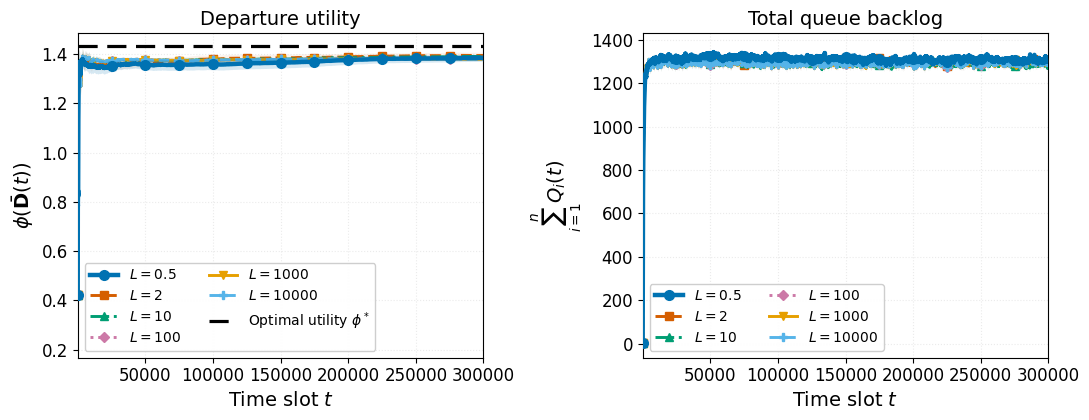

Saved: /content/drive/MyDrive/Markov_Chain_Bandits/Scenario_1/L_Sensitivity/L_Sensitivity.pdf
Saved: /content/drive/MyDrive/Markov_Chain_Bandits/Scenario_1/L_Sensitivity/L_Sensitivity.png
Saved: /content/drive/MyDrive/Markov_Chain_Bandits/Scenario_1/L_Sensitivity/L_Sensitivity.csv


In [ ]:
n = 4
beta = 4
alpha = 3.5
num_sims = 30
c_v, c_d = 0.2,0.5
H = 3*10**5
Ls = [0.5,2,10,100,1000,10000]
states_ = [[0.05,1],[0.05,1],[0.05,1],[0.05,1]]
Ps = [np.array([[0.97,0.03],[0.08,0.92]]), np.array([[0.94,0.06],[0.05,0.95]]), np.array([[0.985,0.015],[0.025,0.975]]),np.array([[0.9,0.1],[0.18,0.82]])]
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Scenario_1/L_Sensitivity"
l_sensitivity(n, beta, H,Ls,c_d,c_v,num_sims,states_,Ps,output_folder)

In [ ]:
##Scenario 2

L =  0.5 Simulation Number: 0
L =  0.5 Simulation Number: 1
L =  0.5 Simulation Number: 2
L =  0.5 Simulation Number: 3
L =  0.5 Simulation Number: 4
L =  0.5 Simulation Number: 5
L =  0.5 Simulation Number: 6
L =  0.5 Simulation Number: 7
L =  0.5 Simulation Number: 8
L =  0.5 Simulation Number: 9
L =  0.5 Simulation Number: 10
L =  0.5 Simulation Number: 11
L =  0.5 Simulation Number: 12
L =  0.5 Simulation Number: 13
L =  0.5 Simulation Number: 14
L =  0.5 Simulation Number: 15
L =  0.5 Simulation Number: 16
L =  0.5 Simulation Number: 17
L =  0.5 Simulation Number: 18
L =  0.5 Simulation Number: 19
L =  0.5 Simulation Number: 20
L =  0.5 Simulation Number: 21
L =  0.5 Simulation Number: 22
L =  0.5 Simulation Number: 23
L =  0.5 Simulation Number: 24
L =  0.5 Simulation Number: 25
L =  0.5 Simulation Number: 26
L =  0.5 Simulation Number: 27
L =  0.5 Simulation Number: 28
L =  0.5 Simulation Number: 29
L =  2 Simulation Number: 0
L =  2 Simulation Number: 1
L =  2 Simulation Number

/tmp/ipykernel_936/4122531912.py:358: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_936/4122531912.py:453: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
/tmp/ipykernel_936/4122531912.py:458: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


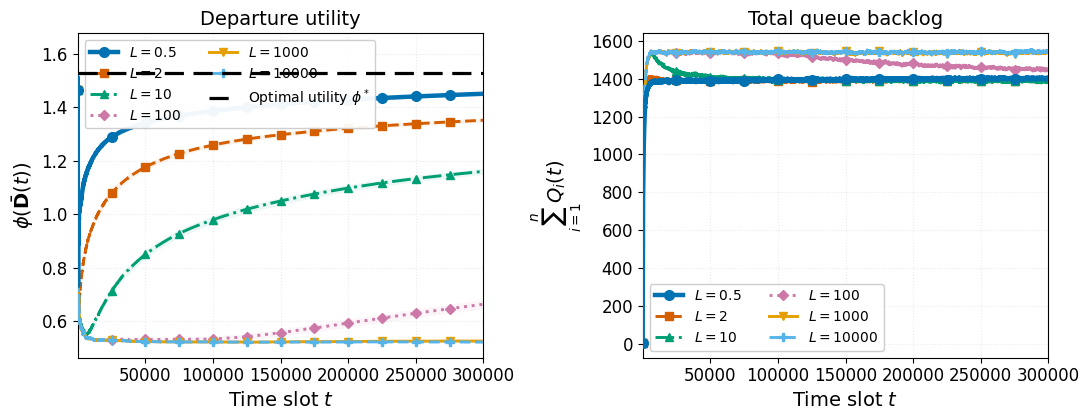

Saved: /content/drive/MyDrive/Markov_Chain_Bandits/Scenario_2/L_Sensitivity/L_Sensitivity.pdf
Saved: /content/drive/MyDrive/Markov_Chain_Bandits/Scenario_2/L_Sensitivity/L_Sensitivity.png
Saved: /content/drive/MyDrive/Markov_Chain_Bandits/Scenario_2/L_Sensitivity/L_Sensitivity.csv


In [ ]:
n = 4
beta = 4
alpha = 3.5
num_sims = 30
c_v, c_d = 0.2,0.5
H = 3*10**5
Ls = [0.5,2,10,100,1000,10000]
states_ = [[0.05,1],[0.05,1],[0.05,1],[0.05,1]]
Ps = [np.array([[0.64,0.36],[0.04,0.96]]), np.array([[0.98,0.02],[0.38,0.62]]), np.array([[0.968,0.032],[0.368,0.632]]),np.array([[0.988,0.012],[0.388,0.612]])]
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Scenario_2/L_Sensitivity"
l_sensitivity(n, beta, H,Ls,c_d,c_v,num_sims,states_,Ps,output_folder)

# Creating Paper Plots


In [1]:
import os
import re
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
import pandas as pd

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## Algo Comparison

In [3]:
def plot_main_2x3(base_folder, output_folder=None, max_points=1500):
    if output_folder is None:
        output_folder = base_folder

    algorithms = [
        "Regenerative UCB",
        "Naive slotwise UCB",
        "Known-mean Regenerative",
        "Known-transition Belief DPP",
        "Uniform",
    ]
    panels = [
        ("ArrivalUtility.csv", "Arrival utility",
         r"$\phi(\bar{\mathbf{A}}(t))$"),
        ("DepartureUtility.csv", "Departure utility",
         r"$\phi(\bar{\mathbf{D}}(t))$"),
        ("TotalQueueSize.csv", "Total queue backlog",
         r"$\sum_{i=1}^{n}Q_i(t)$"),
    ]
    colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
    styles = ["-", "--", "-.", ":", "--"]
    markers = ["o", "s", "^", "D", "v"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex="col")
    legend_lines = {}
    optimal_line = None

    for row, scenario in enumerate((1, 2)):
        for col, (filename, title, ylabel) in enumerate(panels):
            csv_path = os.path.join(
                base_folder, f"Scenario_{scenario}", filename
            )
            full_df = pd.read_csv(csv_path)

            # Sample for drawing only, to keep the PDF small.
            step = max(1, int(np.ceil(len(full_df) / max_points)))
            indices = np.unique(
                np.r_[np.arange(0, len(full_df), step), len(full_df) - 1]
            )
            df = full_df.iloc[indices]
            time = df["Time slot"].to_numpy()

            ax = axes[row, col]
            for j, algorithm in enumerate(algorithms):
                line, = ax.plot(
                    time,
                    df[algorithm].to_numpy(),
                    color=colors[j],
                    linestyle=styles[j],
                    marker=markers[j],
                    markevery=max(1, len(df) // 12),
                    markersize=4.5,
                    linewidth=2.6 if j == 0 else 1.8,
                )
                ax.fill_between(
                    time,
                    df[f"{algorithm} lower 95% CI"].to_numpy(),
                    df[f"{algorithm} upper 95% CI"].to_numpy(),
                    color=colors[j],
                    alpha=0.12,
                    linewidth=0,
                    zorder=1,
                )
                if algorithm not in legend_lines:
                    legend_lines[algorithm] = line

            if col < 2:
                line = ax.axhline(
                    full_df["Optimal utility"].iloc[0],
                    color="black",
                    linestyle=(0, (6, 3)),
                    linewidth=2,
                )
                if optimal_line is None:
                    optimal_line = line

            ax.set_title(f"Scenario {scenario}: {title}")
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.25, linestyle=":")
            ax.margins(x=0)
            ax.locator_params(axis="x", nbins=4)
            if row == 1:
                ax.set_xlabel(r"Time slot $t$")

    handles = [legend_lines[name] for name in algorithms] + [optimal_line]
    labels = algorithms + [r"Optimal utility $\phi^*$"]

    # Make the legend read left to right across each row.
    ncol = 3
    nrows = int(np.ceil(len(handles) / ncol))
    order = [
        row * ncol + col
        for col in range(ncol)
        for row in range(nrows)
        if row * ncol + col < len(handles)
    ]
    handles = [handles[i] for i in order]
    labels = [labels[i] for i in order]

    fig.subplots_adjust(
        left=0.075, right=0.985, top=0.93, bottom=0.22,
        wspace=0.31, hspace=0.34,
    )
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.035),
        ncol=3,
        frameon=False,
        fontsize=11,
    )

    os.makedirs(output_folder, exist_ok=True)
    pdf_path = os.path.join(output_folder, "Main_Results_2x3.pdf")
    png_path = os.path.join(output_folder, "Main_Results_2x3.png")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return pdf_path, png_path

In [ ]:
base = "/content/drive/MyDrive/Markov_Chain_Bandits"
plot_main_2x3(base)

##L-Sensitivity

In [ ]:
def plot_l_sensitivity_2x2(scenario1_csv, scenario2_csv, output_folder, max_points=1500):
    data = [pd.read_csv(scenario1_csv), pd.read_csv(scenario2_csv)]

    pattern = re.compile(r"^L=([0-9.eE+-]+) departure mean$")
    L_values = sorted({
        float(match.group(1))
        for df in data
        for column in df.columns
        if (match := pattern.fullmatch(column))
    })
    if not L_values:
        raise ValueError("No L-sensitivity columns were found in the CSV files.")

    colors = ["#0072B2", "#D55E00", "#009E73",
              "#CC79A7", "#E69F00", "#56B4E9"]
    styles = ["-", "--", "-.", ":", "-", "--"]
    markers = ["o", "s", "^", "D", "v", "P"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")
    legend_lines = {}
    optimal_line = None

    for row, full_df in enumerate(data):
        # Sample for plotting only; the CSV values are unchanged.
        step = max(1, int(np.ceil(len(full_df) / max_points)))
        indices = np.unique(
            np.r_[np.arange(0, len(full_df), step), len(full_df) - 1]
        )
        df = full_df.iloc[indices]
        time = df["Time slot"].to_numpy()

        panels = [
            ("departure", "Departure utility",
             r"$\phi(\bar{\mathbf{D}}(t))$"),
            ("total queue", "Total queue backlog",
             r"$\sum_{i=1}^{n}Q_i(t)$"),
        ]

        for col, (metric, title, ylabel) in enumerate(panels):
            ax = axes[row, col]

            for j, L in enumerate(L_values):
                prefix = f"L={L:g}"
                mean_col = f"{prefix} {metric} mean"
                if mean_col not in df:
                    continue

                color = colors[j % len(colors)]
                line, = ax.plot(
                    time,
                    df[mean_col].to_numpy(),
                    color=color,
                    linestyle=styles[j % len(styles)],
                    marker=markers[j % len(markers)],
                    markevery=max(1, len(df) // 12),
                    linewidth=2.6 if np.isclose(L, 0.5) else 1.8,
                    markersize=5,
                )
                ax.fill_between(
                    time,
                    df[f"{prefix} {metric} lower 95% CI"].to_numpy(),
                    df[f"{prefix} {metric} upper 95% CI"].to_numpy(),
                    color=color,
                    alpha=0.12,
                )

                if metric == "departure" and L not in legend_lines:
                    legend_lines[L] = line

            if metric == "departure":
                line = ax.axhline(
                    full_df["Optimal utility"].iloc[0],
                    color="black",
                    linestyle="--",
                    linewidth=2,
                )
                if optimal_line is None:
                    optimal_line = line

            ax.set_title(f"Scenario {row + 1}: {title}")
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.25, linestyle=":")
            ax.margins(x=0)
            if row == 1:
                ax.set_xlabel(r"Time slot $t$")

    handles = [legend_lines[L] for L in L_values if L in legend_lines]
    labels = [rf"$L={L:g}$" for L in L_values if L in legend_lines]
    handles.append(optimal_line)
    labels.append(r"Optimal utility $\phi^*$")

    # Arrange the two legend rows in left-to-right numerical order.
    ncol = min(4, len(handles))
    nrows = int(np.ceil(len(handles) / ncol))
    order = [
        row * ncol + col
        for col in range(ncol)
        for row in range(nrows)
        if row * ncol + col < len(handles)
    ]
    handles = [handles[i] for i in order]
    labels = [labels[i] for i in order]

    fig.subplots_adjust(
        left=0.09, right=0.98, top=0.94, bottom=0.20,
        wspace=0.25, hspace=0.32,
    )
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.025),
        ncol=ncol,
        frameon=False,
        fontsize=11,
    )

    os.makedirs(output_folder, exist_ok=True)
    pdf_path = os.path.join(output_folder, "L_Sensitivity_2x2.pdf")
    png_path = os.path.join(output_folder, "L_Sensitivity_2x2.png")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return pdf_path, png_path

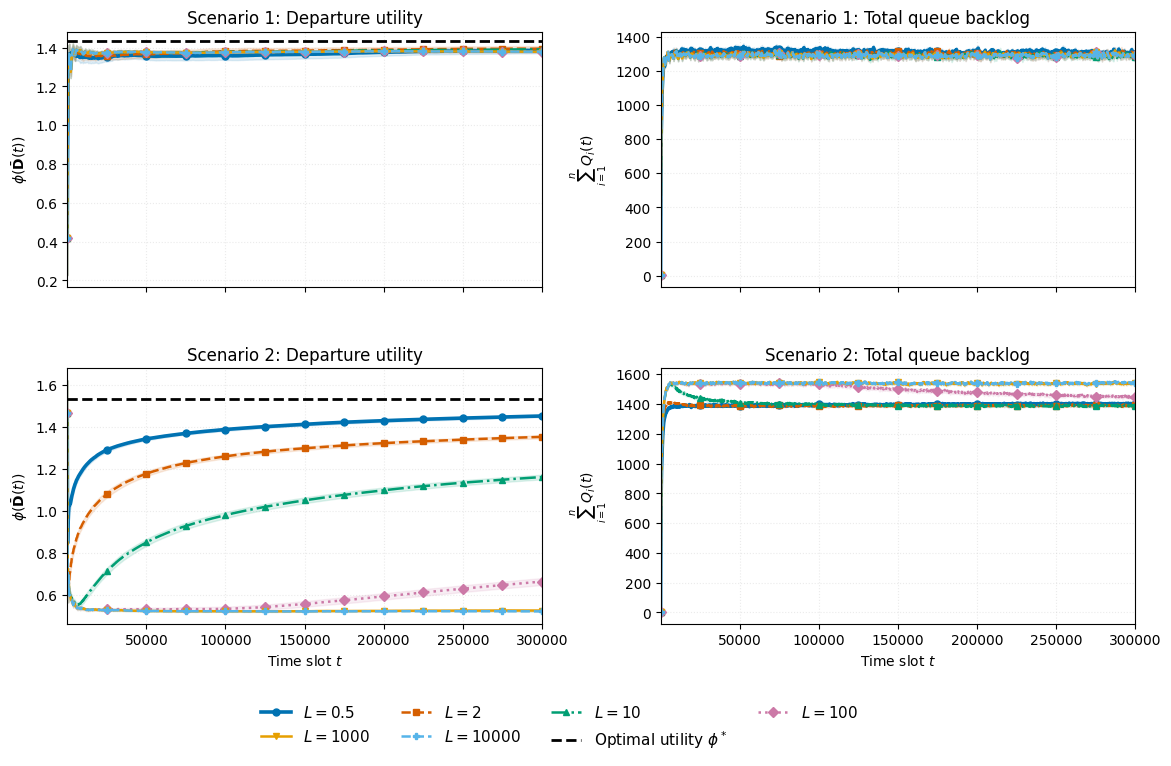

('/content/drive/MyDrive/Markov_Chain_Bandits/L_Sensitivity_2x2.pdf',
 '/content/drive/MyDrive/Markov_Chain_Bandits/L_Sensitivity_2x2.png')

In [ ]:
base = "/content/drive/MyDrive/Markov_Chain_Bandits"
output_folder = "/content/drive/MyDrive/Markov_Chain_Bandits/Paper_Plots"
plot_l_sensitivity_2x2(
    f"{base}/Scenario_1/L_Sensitivity/L_Sensitivity.csv",
    f"{base}/Scenario_2/L_Sensitivity/L_Sensitivity.csv",
    output_folder=output_folder,
)